<a href="https://colab.research.google.com/github/martaorawiec1-star/zara-sales-analysis/blob/main/Zara_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This Zara sales dataset serves as a valuable source for analyzing retail performance and e-commerce activity. It includes detailed sales information collected over a specific period, providing insights into how products perform across Zara stores.

The dataset contains key variables such as product ID, product name, category, price, sales volume, sales date, and store location. This information allows for deeper analysis, including sales forecasting, evaluation of product categories, and assessment of promotional impact.

# 01. Business questions

The following questions were defined to guide this exploratory data analysis:

Which products have the highest and lowest sales?
Which sections and product types generate the most revenue?
How does sales volume vary depending on product placement, promotions, and seasonality?
Which products combine low sales volume with high revenue?
Which combinations of product type and store position perform above the overall average?
Do promotions have a noticeable impact on sales?
Where are the outliers, such as pricing errors or unusual sales patterns?

# 02. Data overview
Description of the variables in the dataset.

* **Product ID:** Numerical identifier for each product allowing to track performance and inventory levels.
* **Product Position:** Location of the product within the store.
* **Promotion:** Indicates whether a product is currently part of a promotional offer.
* **Product Category** Broad classification for the type of product.
* **Seasonal:** Indicates if a product is tied to a specific season, suggesting if a product is a basic or clothing for spring, winter,summer or fall.
* **Sales Volume:** Total number of units of a product sold over a given period.
* **Brand :** specifies the brand name of the product.
* **Url:**  the direct web address leading to the product's page on a website.
* **Sku:** Stock Keeping Unit. It is a unique alphanumeric code assigned to a specific product
* **Name:** Specific name of the product.
* **Description:** Descriptive text from the product's webpage. Which details the product's features, materials, fit, among others.
* **Price:** Retail price of a single unit of the product.
* **Currency:** Currency in which the price is listed.
* **Scraped_at:** This is a timestamp that indicates the exact date and time when the data was collected or "scraped" from the website.
* **Terms:** Represents the specific subcategory or the search query used to gather this particular set of products
* **Section:** Area of the store where the product belongs to. For instance: men's section, women's section, and children's section.

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import iqr

In [ ]:
df = pd.read_csv("Zara_Sales_Analysis.csv", sep=";")
print(df.columns)

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

In [ ]:
# Loading a first 10 rows to understand the data.
print(df.head(10))

   Product ID Product Position Promotion Product Category Seasonal  \
0      185102            Aisle        No         Clothing       No   
1      188771            Aisle        No         Clothing       No   
2      180176          End-cap       Yes         Clothing      Yes   
3      112917            Aisle       Yes         Clothing      Yes   
4      192936          End-cap        No         Clothing      Yes   
5      117590          End-cap        No         Clothing       No   
6      189118   Front of Store       Yes         Clothing      Yes   
7      182157            Aisle        No         Clothing       No   
8      141861            Aisle       Yes         Clothing      Yes   
9      137121            Aisle        No         Clothing      Yes   

   Sales Volume brand                                                url  \
0          2823  Zara  https://www.zara.com/us/en/basic-puffer-jacket...   
1           654  Zara  https://www.zara.com/us/en/tuxedo-jacket-p0889...   
2

In [ ]:
# Analyzing the variety of data in the df
df.nunique()

,0
Product ID,252
Product Position,3
Promotion,2
Product Category,1
Seasonal,2
Sales Volume,234
brand,1
url,228
sku,228
name,194


In [ ]:
print(df.columns)

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')


In [ ]:
# Reviewing duplicated skus
df_duplicated_skus = df[df.duplicated(subset="sku", keep=False)].sort_values(by="sku")

print(df_duplicated_skus.head(6))

     Product ID Product Position Promotion Product Category Seasonal  \
244      118985            Aisle        No         Clothing      Yes   
125      183825            Aisle       Yes         Clothing      Yes   
242      177771          End-cap       Yes         Clothing      Yes   
123      183537   Front of Store       Yes         Clothing      Yes   
110      168571            Aisle        No         Clothing       No   
229      139967          End-cap        No         Clothing       No   

     Sales Volume brand                                                url  \
244           694  Zara  https://www.zara.com/us/en/basic-knit-sweater-...   
125          2989  Zara  https://www.zara.com/us/en/plaid-tie-dye-overs...   
242          1764  Zara  https://www.zara.com/us/en/contrast-topstitchi...   
123          2434  Zara  https://www.zara.com/us/en/paint-print-overshi...   
110          1778  Zara  https://www.zara.com/us/en/pocket-overshirt-p0...   
229          2634  Zara  ht

SKUs are duplicated across different products. They are not related to Product IDs.

# 03. Data cleaning and preparation

In [ ]:
# Renaming all column names to standardize format
df.columns = df.columns.str.lower()
df["name"]=df["name"].str.lower()
df["section"]=df["section"].str.lower()

In [ ]:
# Dropping columns that are not required for this EDA
df.drop(["product category","brand","url","sku","description","currency","scraped_at"], axis='columns', inplace=True)

In [ ]:
# Identifying if there are missing values.

df.isna().sum()

,0
product id,0
product position,0
promotion,0
seasonal,0
sales volume,0
name,1
price,0
terms,0
section,0


In [ ]:
# Updating missing values with "Data not available"
df["name"] = df["name"].fillna("Data not available")


In [ ]:
# Calculating revenue
# In this step we will create a new column to calculte Revenue by multiplying sales volume and price.

df["revenue"]= df ["sales volume"]*df["price"]

The budget-friendly category includes items typically found in thrift shops, dollar stores, and discount retailers, where the average purchase price stays below 25. The standard retail category covers a broad range of products from mid-range stores, with average spending falling between 25 and 75. The upscale retail segment consists of higher-end brands, boutiques, and specialty shops, where purchases usually range from 75 to 200. Finally, the luxury retail category is associated with premium brands and exclusive goods, with average purchases exceeding 200.


In [ ]:
# Setting price ranges

bins = [0, 25, 75, 200, df["price"].max()]
labels = ["Budget-friendly", "Standard", "Upscale", "Luxury"]

df["price category"]= pd.cut(df["price"],bins=bins, labels=labels)
df["price category"].value_counts()

,count
price category,
Upscale,123
Standard,109
Budget-friendly,16
Luxury,4


# 04. Summary statistics

In [ ]:
# Statistics
df[["sales volume","price","revenue"]].describe()

,sales volume,price,revenue
count,252.000000,252.000000,252.000000
mean,1823.702381,86.252540,154716.176508
std,697.703748,52.083205,107025.245299
min,529.000000,7.990000,4330.580000
25%,1243.000000,49.900000,77599.350000
50%,1839.500000,79.900000,129888.250000
75%,2398.750000,109.000000,199768.500000
max,2989.000000,439.000000,651521.000000


# 05. Key performance indicators

In [ ]:
# KPIs

Total_units_sold=df["sales volume"].sum()
print("Total units sold: " +str(Total_units_sold))

Total_revenue=df["revenue"].sum()
print("Total revenue: USD " +str(Total_revenue))

men=df[df["section"]=="man"]
total_men=men["revenue"].sum()
print("Total revenue of men's products: USD "+str(total_men))

women=df[df["section"]=="woman"]
total_women=round(women["revenue"].sum(),2)
print("Total revenue of women's products: USD "+str(total_women))




Total units sold: 459573
Total revenue: USD 38988476.480000004
Total revenue of men's products: USD 35712663.03
Total revenue of women's products: USD 3275813.45


# 06. Data Exploration
## Univariate distribution


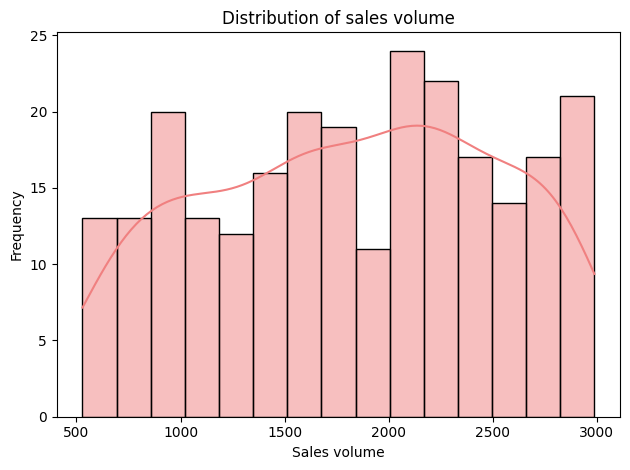

In [ ]:
# Histogram of sales volume

sns.histplot(data=df, x="sales volume", bins=15, color="lightcoral", kde=True)
plt.title("Distribution of sales volume")
plt.xlabel("Sales volume")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The histogram indicates a broad variation in sales volumes across different products. Sales per item range from just over 500 to slightly below 3000. The majority of products record sales between 1500 and 2500.


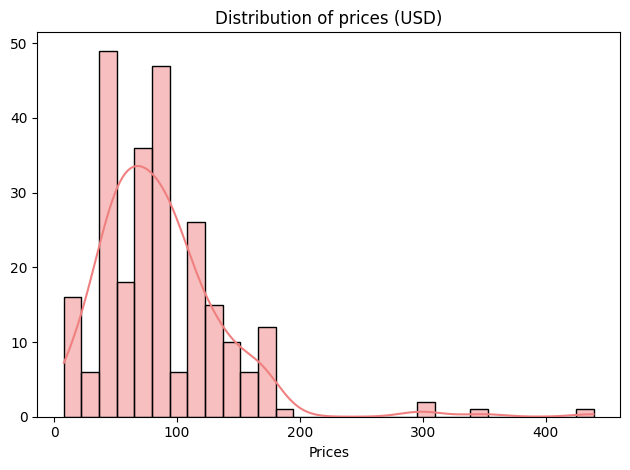

In [ ]:
# Distribution of prices
sns.histplot(data=df, x="price", bins=30, color="lightcoral", kde=True)
plt.title("Distribution of prices (USD)")
plt.xlabel("Prices")
plt.ylabel("")

plt.tight_layout()
plt.show()

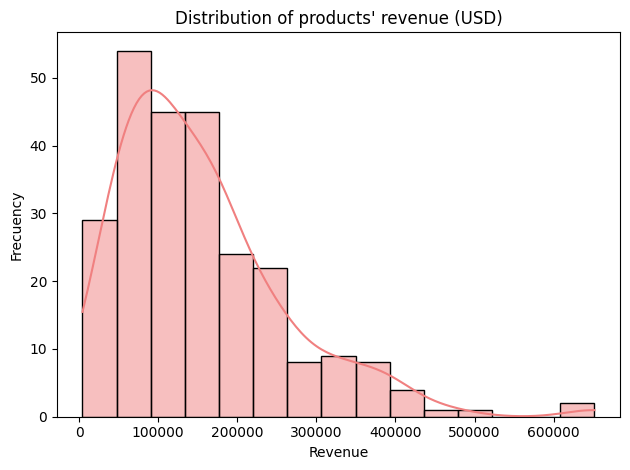

In [ ]:
# Distribution of products' revenue
sns.histplot(data=df, x="revenue", bins=15, color="lightcoral", kde=True)
plt.title("Distribution of products' revenue (USD)")
plt.xlabel("Revenue")
plt.ylabel("Frecuency")

plt.tight_layout()
plt.show()

Most products generated between USD 50,000 and USD 200,000.

Correlation analysis

In [ ]:
print(df.columns)

Index(['product id', 'product position', 'promotion', 'seasonal',
       'sales volume', 'name', 'price', 'terms', 'section', 'revenue',
       'price category'],
      dtype='object')


In [ ]:
df_terms_loc = df.pivot_table(
    values="revenue",
    index="product position",
    columns="terms",
    aggfunc="mean"
)

There is a strong and positive correlaton between product prices and revenue. Sales volume and revenue have a moderate correlation while prices and sales volume do not show any correlation.

# Bivariate analysis

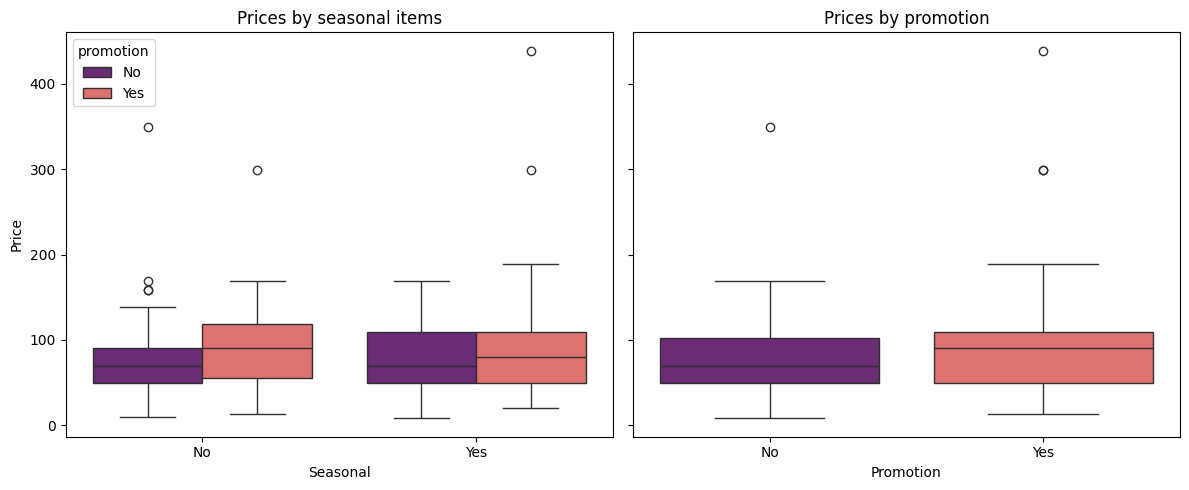

In [ ]:
# Checking if there are outliers by price variable

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

# Chart 1:
sns.boxplot(data=df,x="seasonal",y="price",hue="promotion",palette="magma",ax=axes[0])
axes[0].set_title("Prices by seasonal items")
axes[0].set_xlabel("Seasonal")
axes[0].set_ylabel("Price")

# Chart 2
sns.boxplot(data=df,x="promotion",y="price",hue="promotion",palette="magma",ax=axes[1])
axes[1].set_title("Prices by promotion")
axes[1].set_xlabel("Promotion")
axes[1].set_ylabel("")


fig.tight_layout()
plt.show()

In [ ]:
# Finding outlier in prices

q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)

iqr_val = q3 - q1
lower_threshold = q1 - 1.5 * iqr_val
upper_threshold = q3 + 1.5 * iqr_val

outlier=df[(df["price"]<lower_threshold) | (df["price"]>upper_threshold)]
print(outlier)

    product id product position promotion seasonal  sales volume  \
13      151396   Front of Store       Yes      Yes           729   
22      161909            Aisle       Yes       No          1290   
38      114877            Aisle        No       No          1860   
60      151925          End-cap       Yes      Yes          2179   

                                    name  price    terms section   revenue  \
13                cropped leather jacket  439.0  jackets     man  320031.0   
22                        leather jacket  299.0  jackets     man  385710.0   
38                          suede jacket  349.0  jackets     man  649140.0   
60  vintage effect leather bomber jacket  299.0  jackets     man  651521.0   

   price category  
13         Luxury  
22         Luxury  
38         Luxury  
60         Luxury  


The outliers identified are prices from jackets. The material in common of these jackets is leather. Suede - which is a soft type of leather - has the second highest price, behind a cropped leather jacket which has a price of USD 439.

/tmp/ipykernel_4284/2644884761.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="seasonal",y="sales volume",palette="magma",ax=axes[0])
/tmp/ipykernel_4284/2644884761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="promotion",y="sales volume",palette="magma",ax=axes[1])


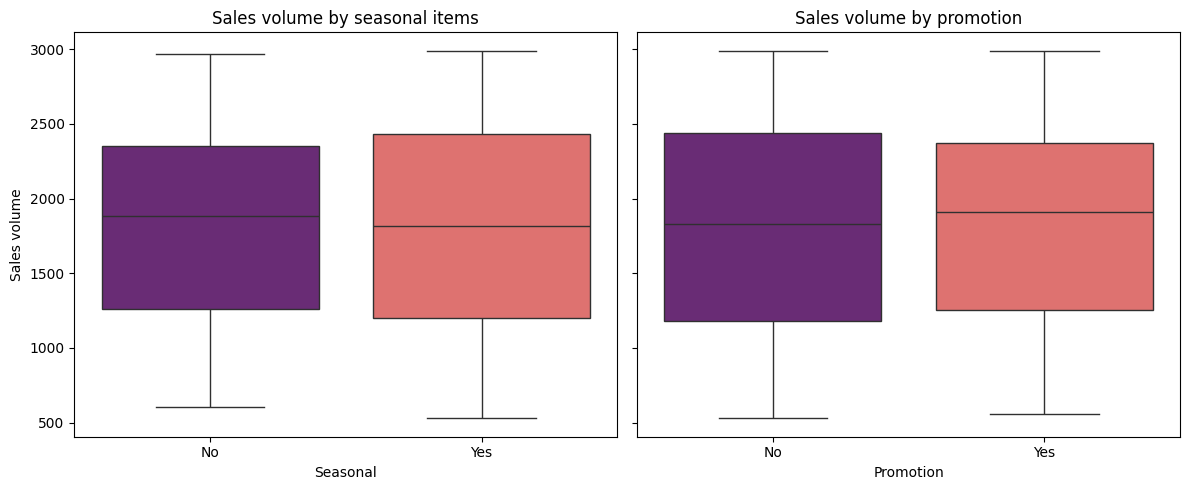

In [ ]:
# Checking if there are outliers by sales volume

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

# Chart 1:
sns.boxplot(data=df,x="seasonal",y="sales volume",palette="magma",ax=axes[0])
axes[0].set_title("Sales volume by seasonal items")
axes[0].set_xlabel("Seasonal")
axes[0].set_ylabel("Sales volume")

# Chart 2
sns.boxplot(data=df,x="promotion",y="sales volume",palette="magma",ax=axes[1])
axes[1].set_title("Sales volume by promotion")
axes[1].set_xlabel("Promotion")
axes[1].set_ylabel("")


fig.tight_layout()
plt.show()

In [ ]:
# Finding outlier in prices

q1_sls = df["sales volume"].quantile(0.25)
q3_sls = df["sales volume"].quantile(0.75)

iqr_val_sls = q3_sls - q1_sls
lower_threshold_sls = q1_sls - 1.5 * iqr_val_sls
upper_threshold_sls = q3_sls + 1.5 * iqr_val_sls

outlier_sls=df[(df["sales volume"]<lower_threshold_sls) | (df["sales volume"]>upper_threshold_sls)]
print(outlier_sls)

Empty DataFrame
Columns: [product id, product position, promotion, seasonal, sales volume, name, price, terms, section, revenue, price category]
Index: []


# Segmentation analysis

/tmp/ipykernel_4284/3026076076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="section",y='sales volume',estimator=sum,palette="rocket",ax=axes[0,0])
/tmp/ipykernel_4284/3026076076.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/3026076076.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/3026076076.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same 

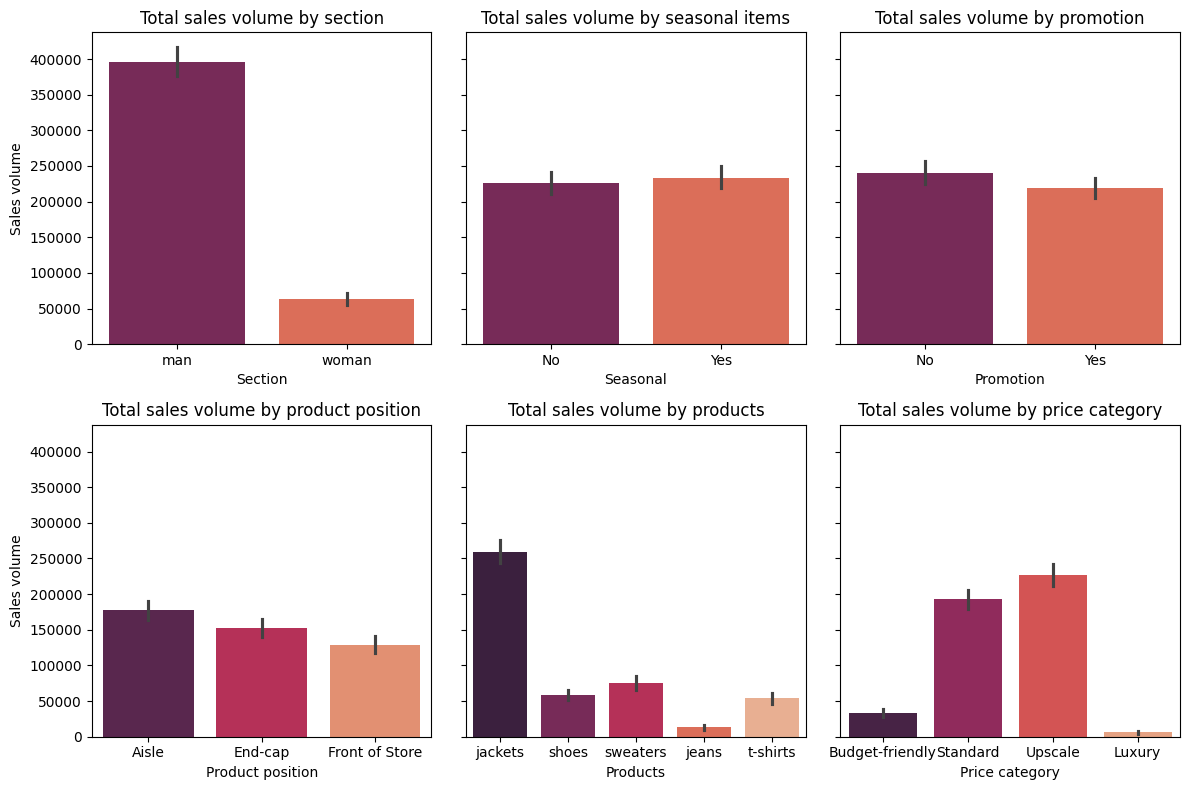

In [ ]:
# Analyzing results for total sales volume by different categories

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)
# Chart 1:
sns.barplot(data=df,x="section",y='sales volume',estimator=sum,palette="rocket",ax=axes[0,0])
axes[0,0].set_title("Total sales volume by section")
axes[0,0].set_xlabel("Section")
axes[0,0].set_ylabel("Sales volume")

# Chart 2:
sns.barplot(
    data=df,x='seasonal',y='sales volume',estimator=sum,palette="rocket",ax=axes[0,1])
axes[0,1].set_title("Total sales volume by seasonal items")
axes[0,1].set_xlabel("Seasonal")
axes[0,1].set_ylabel("")

# Chart 3:
sns.barplot(
    data=df,x='promotion',y='sales volume',estimator=sum,palette="rocket",ax=axes[0,2])
axes[0,2].set_title('Total sales volume by promotion')
axes[0,2].set_xlabel("Promotion")
axes[0,2].set_ylabel("")

# Chart 4
sns.barplot(
    data=df,x="product position",y="sales volume",estimator=sum,palette="rocket",ax=axes[1,0])
axes[1,0].set_title("Total sales volume by product position")
axes[1,0].set_xlabel("Product position")
axes[1,0].set_ylabel("Sales volume")

# Chart 5
sns.barplot(
    data=df,x="terms",y="sales volume",estimator=sum,palette="rocket",ax=axes[1,1])
axes[1,1].set_title("Total sales volume by products")
axes[1,1].set_xlabel("Products")
axes[1,1].set_ylabel("")

# Chart 6
sns.barplot(
    data=df,x="price category",y="sales volume",estimator=sum,palette="rocket",ax=axes[1,2])
axes[1,2].set_title("Total sales volume by price category")
axes[1,2].set_xlabel("Price category")
axes[1,2].set_ylabel("")

fig.tight_layout()
plt.show()


Men’s products generated over 200K more in sales volume compared to women’s. Both seasonal and basic clothing categories maintained relatively stable sales levels. Interestingly, items that were not on promotion slightly outperformed those that were discounted.

When looking at product placement, items positioned in aisles and on end-caps achieved the highest sales volumes, whereas those located at the front of the store performed the weakest.

In terms of product categories, jackets recorded the highest sales with more than 250K units sold, followed by sweaters. On the other hand, jeans had the lowest performance, with sales below 50K units.

Finally, products within the standard and upscale price ranges contributed the most to overall sales volume.

/tmp/ipykernel_4284/636725146.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="section",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,0])
/tmp/ipykernel_4284/636725146.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/636725146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/636725146.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same 

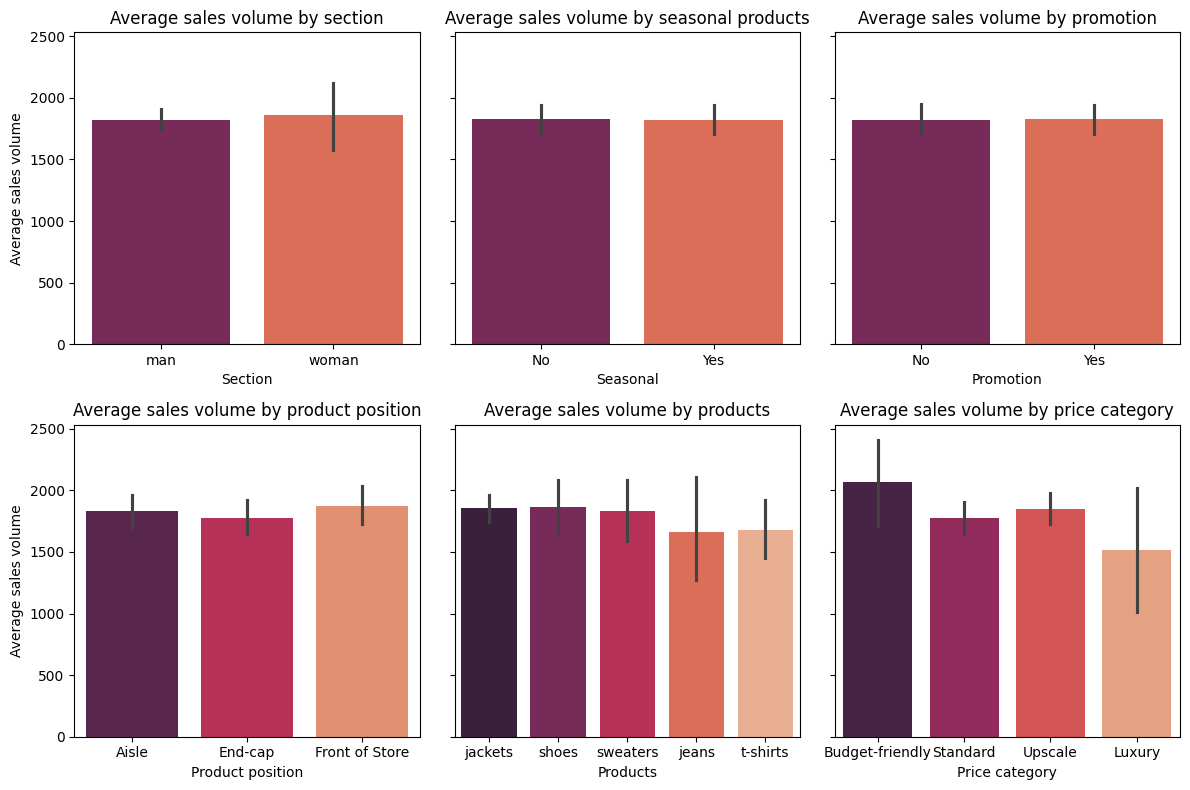

In [ ]:
# Assessing effectiveness of diferent categories
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)
# Chart 1:
sns.barplot(data=df,x="section",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,0])
axes[0,0].set_title("Average sales volume by section")
axes[0,0].set_xlabel("Section")
axes[0,0].set_ylabel("Average sales volume")

# Chart 2:
sns.barplot(
    data=df,x="seasonal",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,1])
axes[0,1].set_title("Average sales volume by seasonal products")
axes[0,1].set_xlabel("Seasonal")
axes[0,1].set_ylabel("")

# Chart 3:
sns.barplot(
    data=df,x="promotion",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,2])
axes[0,2].set_title("Average sales volume by promotion")
axes[0,2].set_xlabel("Promotion")
axes[0,2].set_ylabel("")

# Chart 4
sns.barplot(
    data=df,x="product position",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,0])
axes[1,0].set_title("Average sales volume by product position")
axes[1,0].set_xlabel("Product position")
axes[1,0].set_ylabel("Average sales volume")

# Chart 5
sns.barplot(
    data=df,x="terms",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,1])
axes[1,1].set_title("Average sales volume by products")
axes[1,1].set_xlabel("Products")
axes[1,1].set_ylabel("")

# Chart 6
sns.barplot(
    data=df,x="price category",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,2])
axes[1,2].set_title("Average sales volume by price category")
axes[1,2].set_xlabel("Price category")
axes[1,2].set_ylabel("")

fig.tight_layout()
plt.show()

The charts indicate that there is no significant difference in average sales volume between men and women's section, seasonal and non-seasonal items, nor between products on promotion and those not on promotion.

Regarding product position, items located at the front of the store show a slightly higher average sales volume compared to those placed in aisles or on end-caps. Jackets, shoes and sweaters show a similar sales pattern - outselling jeans and t-shirts by a small margin. Budget-friendly items sold an average of 2K+ items, followed by upscale and standard products (1.8K-1.9K) and lastly, luxury items sold on average around 1.5K items.

/tmp/ipykernel_4284/363981032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="section",y="revenue",estimator=sum,palette="rocket",ax=axes[0,0])
/tmp/ipykernel_4284/363981032.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/363981032.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_4284/363981032.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



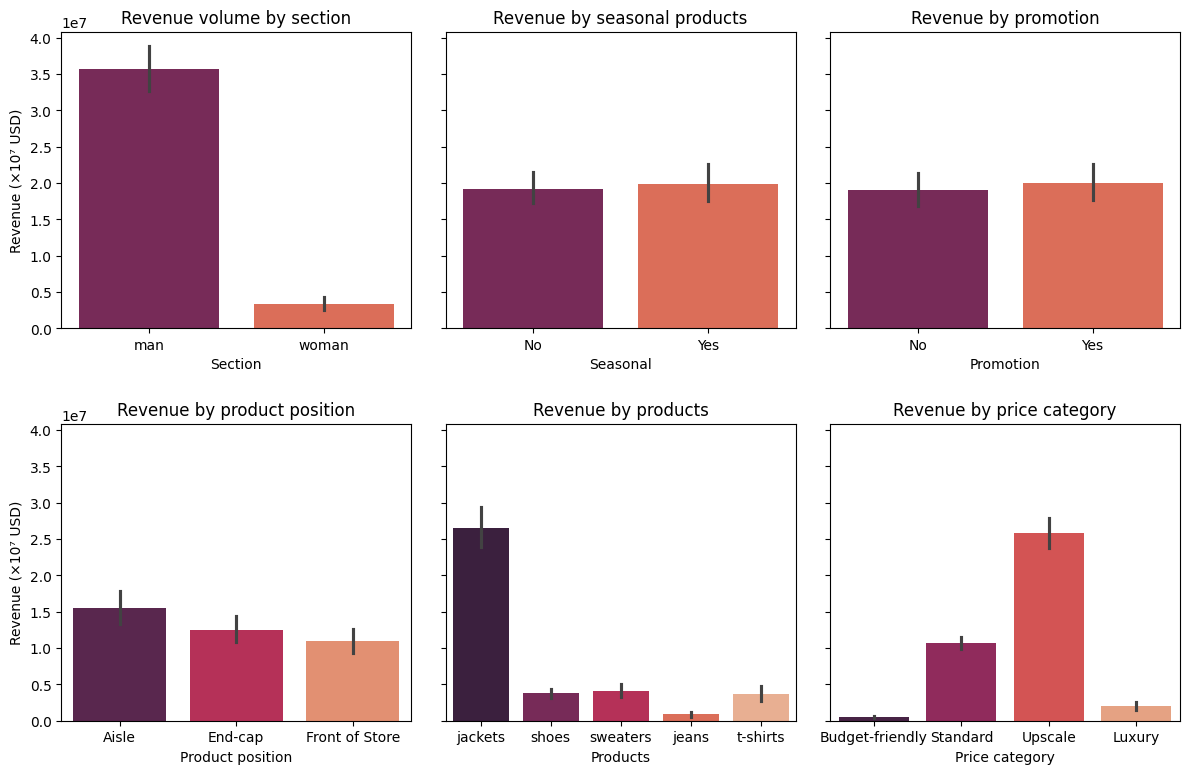

In [ ]:
# Reviewing total revenue by each category
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)
# Chart 1:
sns.barplot(data=df,x="section",y="revenue",estimator=sum,palette="rocket",ax=axes[0,0])
axes[0,0].set_title("Revenue volume by section")
axes[0,0].set_xlabel("Section")
axes[0,0].set_ylabel("Revenue (×10⁷ USD)")

# Chart 2:
sns.barplot(
    data=df,x="seasonal",y="revenue",estimator=sum,palette="rocket",ax=axes[0,1])
axes[0,1].set_title("Revenue by seasonal products")
axes[0,1].set_xlabel("Seasonal")
axes[0,1].set_ylabel("")

# Chart 3:
sns.barplot(
    data=df,x="promotion",y="revenue",estimator=sum,palette="rocket",ax=axes[0,2])
axes[0,2].set_title("Revenue by promotion")
axes[0,2].set_xlabel("Promotion")
axes[0,2].set_ylabel("")

# Chart 4
sns.barplot(
    data=df,x="product position",y="revenue",estimator=sum,palette="rocket",ax=axes[1,0])
axes[1,0].set_title("Revenue by product position")
axes[1,0].set_xlabel("Product position")
axes[1,0].set_ylabel("Revenue (×10⁷ USD)")

# Chart 5
sns.barplot(
    data=df,x="terms",y="revenue",estimator=sum,palette="rocket",ax=axes[1,1])
axes[1,1].set_title("Revenue by products")
axes[1,1].set_xlabel("Products")
axes[1,1].set_ylabel("")

# Chart 6
sns.barplot(
    data=df,x="price category",y="revenue",estimator=sum,palette="rocket",ax=axes[1,2])
axes[1,2].set_title("Revenue by price category")
axes[1,2].set_xlabel("Price category")
axes[1,2].set_ylabel("")

fig.tight_layout()
plt.show()

Jackets clearly led all categories in revenue generation, surpassing USD 26M by a wide margin. Sweaters secured the second position with approximately USD 4M in revenue. T-shirts and shoes demonstrated comparable performance levels, each contributing close to USD 3M. In contrast, jeans significantly lagged behind other categories, generating only slightly above USD 8.5K.

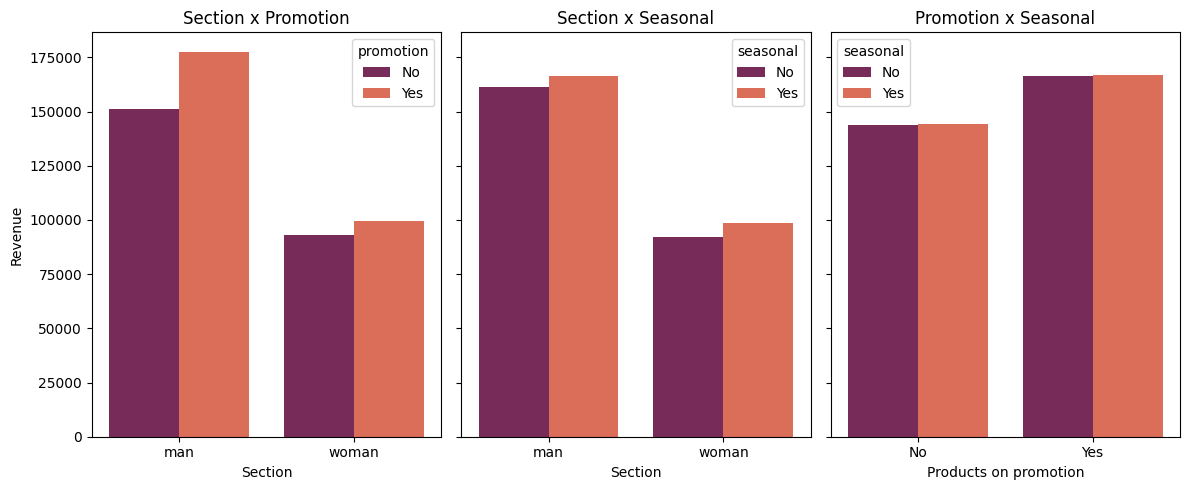

In [ ]:
# Key variables comparisson
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5), sharey=True)

# Chart 1
sns.barplot(data=df,x="section",y="revenue",hue="promotion", palette="rocket",errorbar=None, ax=axes[0])
axes[0].set_title("Section x Promotion")
axes[0].set_xlabel("Section")
axes[0].set_ylabel("Revenue")

# Chart 2
sns.barplot(data=df,x="section",y="revenue",hue="seasonal", palette="rocket", errorbar=None,ax=axes[1])
axes[1].set_title("Section x Seasonal")
axes[1].set_xlabel("Section")
axes[1].set_ylabel("")

# Chart 3
sns.barplot(data=df, x="promotion", y="revenue", hue="seasonal", palette="rocket", errorbar=None,ax=axes[2])
axes[2].set_title("Promotion x Seasonal")
axes[2].set_xlabel("Products on promotion")
axes[2].set_ylabel("")


plt.tight_layout()
plt.show()

Products from the men’s section generate considerably more revenue compared to those in the women’s section. Promotions seem to have a greater effect on men’s products, contributing to increased sales. Seasonal items achieve slightly higher revenue than non-seasonal ones across both sections. Overall, promoted products tend to perform better, although the effectiveness of promotions does not appear to be strongly influenced by seasonality.

In [ ]:
# Price category x section: sales volume, revenue and price average.
df.groupby(["price category", "section"], observed=True).agg(
    sales_volume=("sales volume", "sum"),
    avg_price=("price","mean"),
    revenue_sum=("revenue", "sum"),
    count=("section", "count")
).reset_index()

,price category,section,sales_volume,avg_price,revenue_sum,count
0,Budget-friendly,man,29812,16.548571,480546.74,14
1,Budget-friendly,woman,3285,7.990000,26247.15,2
2,Standard,man,137392,57.902278,7971994.09,79
3,Standard,woman,55781,48.433333,2676191.90,30
4,Upscale,man,222937,114.262810,25253720.20,121
5,Upscale,woman,4308,124.450000,573374.40,2
6,Luxury,man,6058,346.500000,2006402.00,4


In [ ]:
# Products x promotion: sales volume, revenue and price average.
df.groupby(["terms", "promotion"], observed=True).agg(
    sales_volume=("sales volume", "sum"),
    avg_price=("price","mean"),
    revenue_sum=("revenue", "sum"),
    revenue_avg=("revenue", "mean"),
    count=("terms", "count")
).reset_index()

,terms,promotion,sales_volume,avg_price,revenue_sum,revenue_avg,count
0,jackets,No,134416,96.277083,12573916.27,174637.725972,72
1,jackets,Yes,125052,115.796471,14007899.60,205998.523529,68
2,jeans,No,8611,63.900000,573798.90,114759.780000,5
3,jeans,Yes,4709,63.963333,290586.35,96862.116667,3
4,shoes,No,28560,57.378667,1610254.23,107350.282000,15
5,shoes,Yes,29346,71.900000,2144583.40,134036.462500,16
6,sweaters,No,38461,59.007391,2274241.58,98880.068696,23
7,sweaters,Yes,36781,49.566667,1816389.90,100910.550000,18
8,t-shirts,No,30264,69.217647,1961878.60,115404.623529,17
9,t-shirts,Yes,23373,65.399333,1734927.65,115661.843333,15


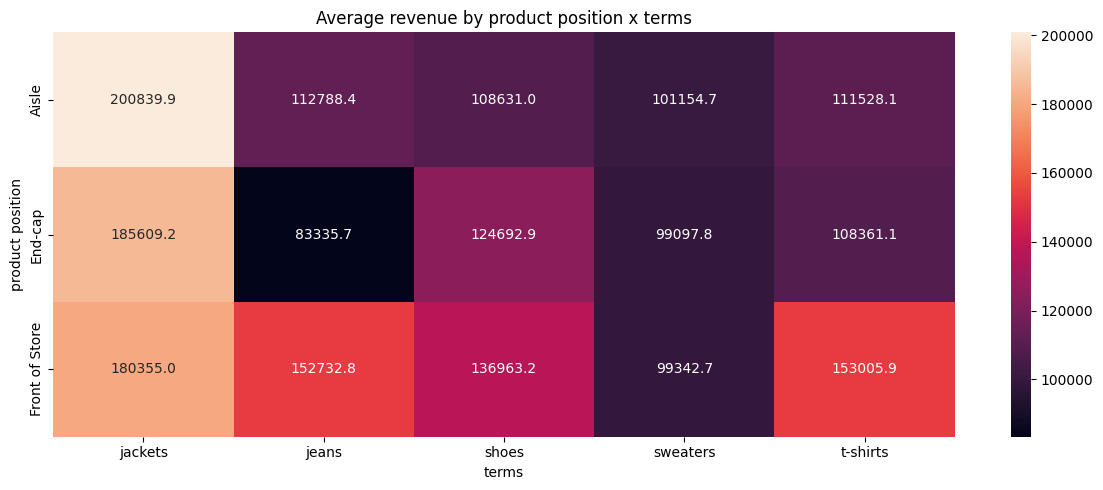

In [ ]:
# Heatmap product position x terms
df_terms_loc = df.pivot_table(index="product position", columns="terms",values="revenue",aggfunc="mean")


plt.figure(figsize=(12, 5))
sns.heatmap(df_terms_loc, cmap="rocket", annot=True, fmt=".1f")
plt.title("Average revenue by product position x terms")

plt.tight_layout()
plt.show()


Jackets had the highest average revenue in the store, performing above the overall average of USD 154,716. Sweaters, on the other hand, showed consistently low performance.

Shoes and t-shirts both generated over USD 100K in revenue across different store areas, which suggests steady and balanced performance.

Revenue from jeans varied depending on product placement. The front-of-store position had the highest revenue (over USD 152K), followed by the aisle (over USD 112K), while the end-cap had the lowest revenue (under USD 85K).

/tmp/ipykernel_4284/3818311869.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_rev_price = df.pivot_table(index="price category", columns="terms",values="revenue",aggfunc="mean")


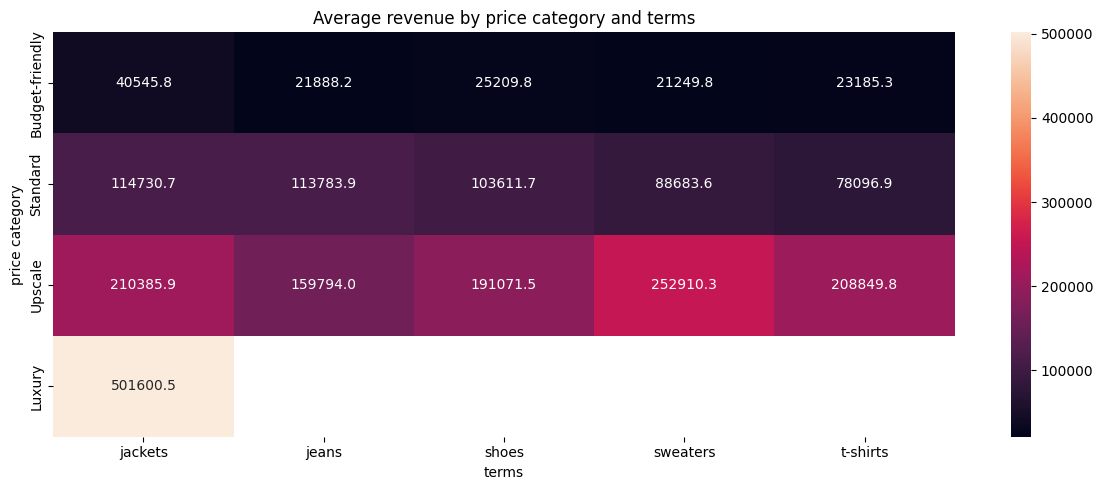

In [ ]:
# Revenue by price category x terms
df_rev_price = df.pivot_table(index="price category", columns="terms",values="revenue",aggfunc="mean")

plt.figure(figsize=(12, 5))
sns.heatmap(df_rev_price, cmap="rocket", annot=True, fmt=".1f")
plt.title("Average revenue by price category and terms")

plt.tight_layout()
plt.show()

Luxury jackets generated more than three times the average revenue, making them some of the most valuable products in the Zara range. Items in the upscale category also performed very well, with all of them exceeding the overall average revenue. Notably, upscale sweaters ranked second in terms of average revenue, just behind luxury jackets.

In comparison, products in the standard category showed average performance, with revenues between USD 78K and USD 114K. Budget-friendly items performed the weakest, recording the lowest revenue across all categories.

Overall, the results indicate that customers tend to favor higher-priced products over cheaper ones, possibly because they perceive them as better quality or more valuable.

Text(0.5, 1.03, 'Sales Volume vs Revenue by Product, Price Category, and Position')

<Figure size 1600x800 with 0 Axes>

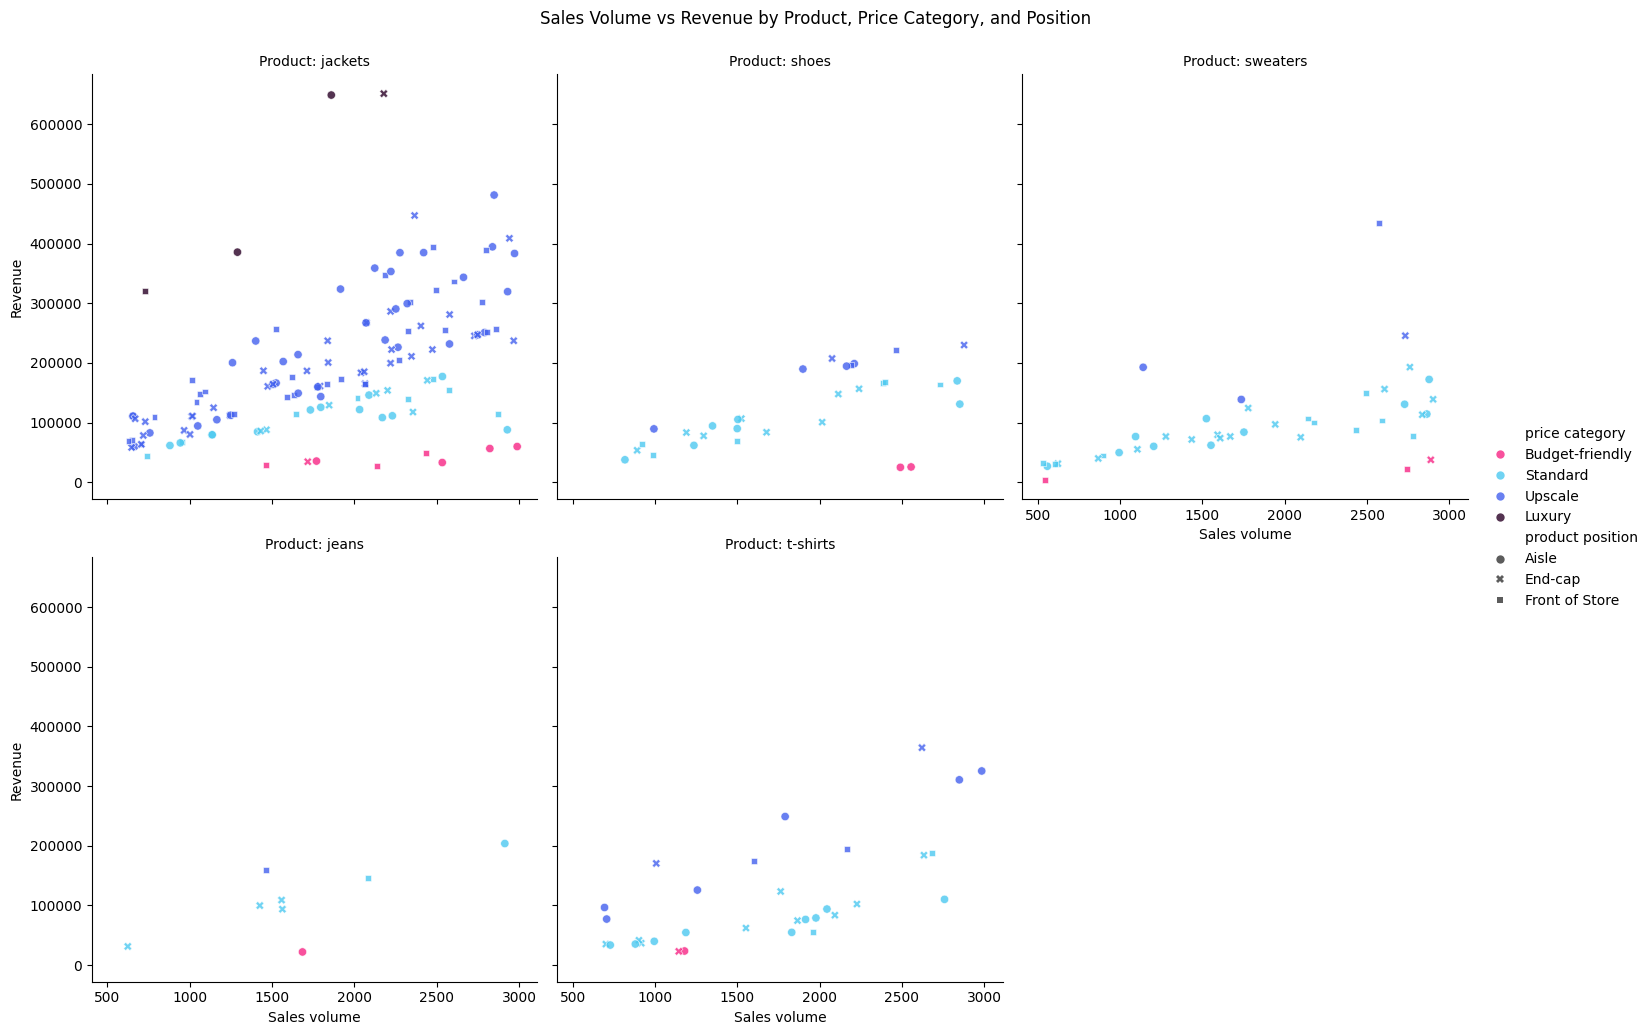

In [ ]:
# Relationship between sales volume x revenue and product, price category and product position
plt.figure(figsize=(16, 8))

palette = ["#F72585","#4CC9F0","#4361EE","#290025"]

g = sns.relplot(data=df,x="sales volume",y="revenue",col="terms",col_wrap=3,
                style="product position",hue="price category",
                alpha=0.8,palette=palette)

g.set_axis_labels("Sales volume", "Revenue")
g.set_titles(col_template="Product: {col_name}")
g.fig.suptitle("Sales Volume vs Revenue by Product, Price Category, and Position", y=1.03)

Revenue increased across all product types as sales volume grew. Jackets showed the most consistent and strong performance across the store, with upscale jackets achieving the highest unit sales in every placement. Luxury jackets displayed more variability—some generated over USD 300K with fewer than 1,000 units sold, while others reached around USD 600K with roughly double the sales volume. Standard jackets followed a steady upward trend but delivered lower overall revenue, while budget-friendly jackets remained below USD 100K despite continuous growth in sales volume.

Shoes and sweaters followed a similar trend. Most standard items saw increasing sales volumes but generated less than USD 200K in revenue. Although there were more upscale products in the shoes category, their revenue levels were comparable to sweaters. Upscale items placed on end-caps sold a similar number of units and generated between USD 200K and USD 250K in revenue.

For jeans, standard items positioned on end-caps generated higher revenue, whereas those placed at the front of the store and in aisles achieved higher sales volumes. Interestingly, even though upscale jeans sold fewer units than budget-friendly ones, they still reached close to USD 200K in revenue.

Finally, t-shirts performed better in the upscale category compared to standard items. Products placed in aisles recorded the highest sales, outperforming those located at the front of the store or on end-caps.

# Best and worst performers

/tmp/ipykernel_4284/393145856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10,x="revenue",y="name",palette="flare")


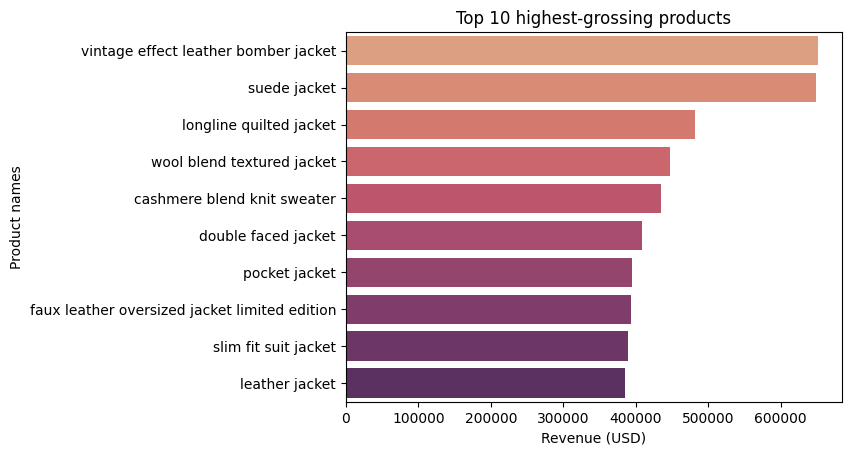

In [ ]:
# Top ten highest-grossing products
top_10 = df.sort_values("revenue", ascending=False).iloc[:10]

#create bar chart to visualize top 10 values
sns.barplot(data=top_10,x="revenue",y="name",palette="flare")
plt.title("Top 10 highest-grossing products")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product names")
plt.show()

Most highest-grossing products are jackets, with vintage effect leather and suede jackets being the top 2 products that generated over USD 600,000.

/tmp/ipykernel_4284/1234752521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sales,x="sales volume",y="name",palette="flare")


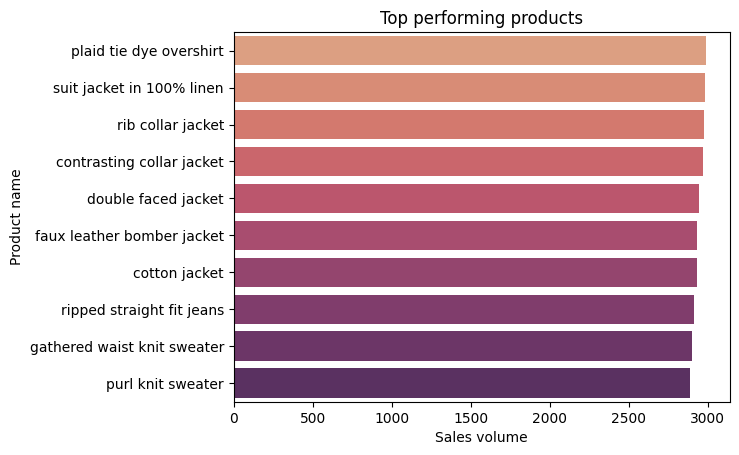

In [ ]:
# Top ten best selling products

top_10_sales = df.sort_values("sales volume", ascending=False).iloc[:10]

sns.barplot(data=top_10_sales,x="sales volume",y="name",palette="flare")
plt.title("Top performing products")
plt.ylabel("Product name")
plt.xlabel("Sales volume")
plt.show()

Zara’s top-performing products cover a range of categories, including sweaters, jeans, jackets, and an overshirt, with each item selling more than 2,500 units.

/tmp/ipykernel_4284/4087504561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10,x="revenue",y="name",palette="flare")


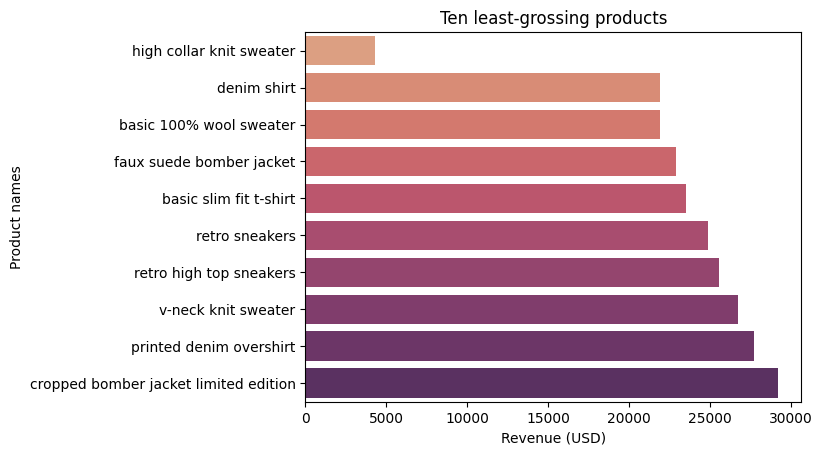

In [ ]:
# Ten least-grossing products
top_10 = df.sort_values("revenue", ascending=True).iloc[:10]

sns.barplot(data=top_10,x="revenue",y="name",palette="flare")
plt.title("Ten least-grossing products")
plt.xlabel("Revenue (USD)")
plt.ylabel("Product names")
plt.show()

The least successful products recorded sales of around 500 to 600 units each. In particular, abstract jacquard, high-collar knit, and V-neck knit sweaters had the lowest performance, with sales below 550 units.

# Best and worst-selling products




The top five best-selling products included the plaid tie-dye overshirt, a 100% linen jacket, two collar jacket styles, and a double-faced jacket, each reaching approximately 280K units sold. In contrast, the lowest-performing items were primarily knitwear, including an abstract jacquard sweater and four other knit sweaters.

# Revenue by section and product type
The men’s section generated higher revenue compared to the women’s section. Among product categories, jackets were the leading contributors, generating around USD 25M. Similarly, products in the upscale category accounted for the highest overall revenue, also reaching approximately USD 25M.

# Sales volume by placement, promotion, and seasonality
On average, sales volume remained relatively consistent across product position, promotion status, and seasonality, generally ranging between 150K and 200K units. In terms of total sales, there was little difference between seasonal and non-seasonal items, as well as between promoted and non-promoted products. However, product placement showed some variation: items at the front of the store sold below 150K units, end-cap items reached around 150K, while aisle placements performed best with close to 200K units sold.

Low volume, high revenue products
Certain products generated high revenue despite lower sales volumes. For example, luxury jackets sold fewer than 1,000 units but generated over USD 300K in revenue. Upscale sweaters followed a similar pattern, with under 1,300 units sold and revenues of around USD 200K.

Top-performing combinations (terms × position)
Jackets achieved the highest average revenue across all store placements, exceeding the overall average of USD 154,716. Jeans and t-shirts positioned at the front of the store also performed well, with average revenues of approximately USD 152K and USD 153K, respectively.

Impact of promotions
Promotions did not appear to significantly influence sales performance. Both promoted and non-promoted products recorded similar average sales volumes, generally exceeding 1.6K units.

Outliers
Outliers were identified in product pricing, particularly among men’s jackets. Four items were priced significantly higher than the rest, ranging from USD 299 to USD 439.

# 08. Recommendations

Given that jackets show similar performance whether promoted or not, the current promotion strategy should be reviewed. Reducing the number of discounted items could help maximize revenue for this category.

It is also recommended to test alternative product placements for lower-performing items. For example, relocating sweaters to high-visibility areas such as aisles or end-caps could help improve their sales performance.

Finally, expanding the range of luxury products in both sections could be beneficial. Although these items sell in lower volumes, they generate significantly higher revenue, often outperforming standard products.

In [ ]:
df_final = df.copy()

df_final = df_final[[
    "name",
    "section",
    "terms",
    "price",
    "sales volume",
    "revenue",
    "price category",
    "promotion",
    "seasonal",
    "product position"
]]

In [ ]:
df_final.to_csv("zara_final.csv", index=False)